# 01 - Exploratory Data Analysis

**Phase 1 (Weeks 1-2)** of the Portuguese wildfire catastrophe loss model.

This notebook loads a real per-fire wildfire database for Portugal and
explores the resulting frequency and severity patterns.

See `docs/phase1-plan.md` and `docs/worklog.md` in the repo root for the
full data-sourcing story. In short:

- The primary data source is EFFIS's own Rapid Damage Assessment (MODIS-
  based) fire database, obtained via EFFIS's official Data Request Form
  (a one-time manual submission, since EFFIS's live Statistics Portal has
  no public JSON API). This gives real per-fire dates, real NUTS2 region
  locations, and real burned areas for mainland Portugal, 2009-2025.
- The MODIS-era product maps fires of roughly 30 ha or larger (per EFFIS's
  own documentation), an estimated 75-80% of total burnt area despite being
  a minority of total fire count. From 2019 the export switches to
  Sentinel-2 and includes fires down to 1 ha, so **a "fire event" in this
  model means a mapped fire of at least 30 ha, applied explicitly and
  uniformly to every year** (`MIN_FIRE_AREA_HA`), not every ignition and not
  whatever each sensor happened to map - see "Why the size threshold is
  applied explicitly" below.
- No public source publishes verified EUR loss per individual fire. A
  documented EUR/ha calibration constant (derived from published ICNF/OECD
  aggregate figures) is applied to real burned areas instead.
- Live OWID/GWIS annual aggregates are still fetched, but only as an
  independent cross-check against the real per-fire data, not as a
  modeling input. See "Data gaps and assumptions" below for what that
  cross-check found.

## Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import requests

from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY = "Portugal"
START_YEAR = 2009  # first full season in the EFFIS export (it starts 2008-04-26; 2008 has only 33 records)
MAX_YEAR = 2025    # 2025 is provisional; the export also holds 2026, a partial year, which is excluded
EFFIS_FILE = RAW_DIR / "effis_fire_database_pt_2008_2026.csv"
# EFFIS mapped fires below this size are not comparable across the whole window: the
# mapping source changes from MODIS (2009-2018, ~12-24 ha minimum) to Sentinel-2 (2020-2025,
# down to 1 ha), so raw counts are not a stationary series. Applied uniformly to every year.
MIN_FIRE_AREA_HA = 30

# Loss is expressed in 2025 euros (PRD) and, per fire, also in the euros of the fire's own year.
PRICE_BASE_YEAR = 2025
# Price year assumed for the ICNF-derived long-run EUR/ha figure. Its true basis is a cumulative
# 1975-2021 total in mixed-year euros and is unknown; 2021 (last year of the series) gives the
# smallest possible uplift to 2025 prices, so this is a floor, not a best estimate.
CENTRAL_PRICE_YEAR = 2021


## Data loading

`load_effis_fire_database` reads the real, committed per-fire snapshot
(the primary data source). `fetch_annual_fire_counts` and
`fetch_annual_burnt_area` pull live OWID/GWIS aggregates used only for
cross-validation further down, not as modeling inputs.

In [2]:
def load_effis_fire_database(path: Path = EFFIS_FILE,
                             min_area_ha: float = MIN_FIRE_AREA_HA,
                             mainland_only: bool = True,
                             start_year: int = START_YEAR,
                             end_year: int = MAX_YEAR) -> pd.DataFrame:
    """Load the real per-fire EFFIS Rapid Damage Assessment database for Portugal.

    Source: EFFIS's official Data Request Form (forest-fire.emergency.
    copernicus.eu/apps/data.request.form/), dataset "Burnt area mapped
    using Sentinel2/MODIS images", Portugal. A one-time manual export (not
    a live API), so this file is a static, committed snapshot with no
    reproducibility drift. It runs from 2008-04-26 to 2026-09-17; its
    2010-2024 records are identical to an earlier export (same ids, areas,
    dates and locations). See the .readme.txt beside it.

    Per EFFIS's own documentation, this product maps fires of roughly 30 ha
    or larger, which still represents an estimated 75-80% of Portugal's
    total burnt area despite being a minority of total fire count. That only
    holds for the MODIS-era records (to 2018): from 2019 the export's
    `map_source` switches to Sentinel-2 and records as small as 1 ha appear
    (63-82% of 2020-2025 rows are under 30 ha), which would make annual
    counts ~3x higher for a sensor reason, not a hazard reason. The following
    steps are therefore applied, in this order:

    1. Mainland only: records outside mainland Portugal (`admlvl1` other
       than "Continente") are dropped, since Madeira and the Azores behave
       differently and are out of scope.
    2. Year window `start_year`..`end_year`: 2008 is dropped (the export
       starts 2008-04-26 and holds only 33 records that year) and 2026 is
       dropped (a partial year). 2025 is kept but is provisional.
    3. Records with `area_ha <= 0` are dropped as non-physical mapping
       artifacts (EFFIS's own caveats about small/unmapped islands within a
       burn scar).
    4. Exact duplicate records (same parish, area and timestamp logged under
       a different id) are removed, keeping the first copy; all are tiny
       fires, see docs/worklog.md for how this was found.
    5. Only fires of at least `min_area_ha` are kept (default
       MIN_FIRE_AREA_HA = 30), so frequency and severity are defined on the
       same size threshold in every year.

    Parameters
    ----------
    path : Path
        Location of the committed raw EFFIS export.
    min_area_ha : float
        Minimum burned area for a record to count as a fire event.
    mainland_only : bool
        Keep only mainland Portugal (`admlvl1 == "Continente"`).
    start_year, end_year : int
        Inclusive year window, by fire start date.

    Returns
    -------
    pd.DataFrame
        Columns: Date, Location, Burned_Area_ha - one row per real mapped
        fire event, sorted by date.
    """
    df = pd.read_csv(path, encoding="utf-8")
    df["Date"] = pd.to_datetime(df["initialdate"], format="mixed")
    if mainland_only:
        df = df[df["admlvl1"] == "Continente"]
    df = df[df["Date"].dt.year.between(start_year, end_year)]
    df = df[df["area_ha"] > 0]
    df = df.drop_duplicates(subset=["admlvl5", "area_ha", "initialdate"], keep="first")
    df = df[df["area_ha"] >= min_area_ha]

    result = df.rename(columns={"admlvl2": "Location", "area_ha": "Burned_Area_ha"})
    return result[["Date", "Location", "Burned_Area_ha"]].sort_values("Date").reset_index(drop=True)


### Why the size threshold is applied explicitly

The export's mapping source changes over time, and the smallest mapped fire
changes with it. The table below is computed from the raw file before any
size filter.


In [3]:
raw = pd.read_csv(EFFIS_FILE, encoding="utf-8")
raw = raw[raw["admlvl1"] == "Continente"]  # mainland only, as in load_effis_fire_database
raw["year"] = pd.to_datetime(raw["initialdate"], format="mixed").dt.year
raw = raw[raw["year"].between(START_YEAR, MAX_YEAR)]
raw = raw[raw["area_ha"] > 0].drop_duplicates(subset=["admlvl5", "area_ha", "initialdate"])

mapping_break = raw.groupby("year").agg(
    map_source=("map_source", lambda s: "/".join(sorted(s.unique()))),
    records=("area_ha", "size"),
    min_area_ha=("area_ha", "min"),
    pct_under_threshold=("area_ha", lambda a: (a < MIN_FIRE_AREA_HA).mean() * 100),
).round(1)
print(mapping_break)

before = raw.groupby("year").size()
after = raw[raw["area_ha"] >= MIN_FIRE_AREA_HA].groupby("year").size()
print()
print(f"Mean records/year, unfiltered:   2009-2019 {before.loc[:2019].mean():.0f}   2020-2025 {before.loc[2020:].mean():.0f}")
print(f"Mean records/year, >= {MIN_FIRE_AREA_HA} ha:      2009-2019 {after.loc[:2019].mean():.0f}   2020-2025 {after.loc[2020:].mean():.0f}")


           map_source  records  min_area_ha  pct_under_threshold
year                                                            
2009            modis      342           23                  5.8
2010            modis      305           20                  4.9
2011            modis      319           20                  5.0
2012            modis      235           15                  5.1
2013            modis      359           12                  9.2
2014            modis       35           24                  2.9
2015            modis      177           16                  4.5
2016            modis      320           19                  3.1
2017            modis      411           22                  1.5
2018            modis       86           20                  9.3
2019  modis/sentinel2      217           21                 22.6
2020        sentinel2      462            1                 62.8
2021        sentinel2      745            1                 74.9
2022        sentinel2    

In [4]:
def fetch_annual_fire_counts(country: str = COUNTRY,
                              save_path: Path = RAW_DIR / "effis_annual_fire_counts.csv") -> pd.DataFrame:
    """Fetch annual wildfire counts for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS (Global Wildfire Information
    System, JRC/Copernicus) annual fire-count series, VIIRS/MODIS-detection
    based and covering *all* fire sizes. Not used as the model's frequency
    source (see load_effis_fire_database) - kept only to cross-check
    against the real large-fire-only counts, since the two series measure
    different things and are not expected to reconcile (see "Data gaps and
    assumptions").

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, fire_count (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-number-of-fires.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Annual number of fires": "fire_count"}
    )
    return df[["year", "fire_count"]].sort_values("year").reset_index(drop=True)

In [5]:
def fetch_annual_burnt_area(country: str = COUNTRY,
                             save_path: Path = RAW_DIR / "gwis_annual_burnt_area.csv") -> pd.DataFrame:
    """Fetch annual burnt area (hectares) for a country (cross-validation reference only).

    Source: Our World in Data's mirror of GWIS's MODIS-derived annual
    burnt-area-by-region series, covering *all* fire sizes. Used below to
    check what share of total burnt area the real large-fire-only dataset
    captures, not as a modeling input.

    Parameters
    ----------
    country : str
        Country name as it appears in the source's "Entity" column.
    save_path : Path
        Where to save the raw fetched CSV (all countries, unfiltered).

    Returns
    -------
    pd.DataFrame
        Columns: year, burnt_area_ha (filtered to the requested country).
    """
    url = "https://ourworldindata.org/grapher/annual-area-burnt-by-wildfires-gwis.csv"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    save_path.write_text(response.text, encoding="utf-8")

    df = pd.read_csv(save_path)
    df = df[df["Entity"] == country].rename(
        columns={"Year": "year", "Yearly burned area across all land types": "burnt_area_ha"}
    )
    return df[["year", "burnt_area_ha"]].sort_values("year").reset_index(drop=True)

In [6]:
def fetch_hicp(geo: str = "PT", save_path: Path = RAW_DIR / "pt_hicp_annual.csv") -> pd.Series:
    """Fetch the annual HICP (all-items) index for a country, used to restate euros across years.

    Source: Eurostat dataset prc_hicp_aind (annual average index, 2015 = 100,
    all items). A general consumer price index, not a construction-cost index,
    so it may understate or overstate reconstruction-cost inflation. Like the
    OWID series, the fetched values are committed as a snapshot so a rerun is
    pinned; the year cap keeps the series inside the model window.

    Parameters
    ----------
    geo : str
        Eurostat country code.
    save_path : Path
        Where to save the fetched series.

    Returns
    -------
    pd.Series
        HICP index (2015 = 100) indexed by year, up to MAX_YEAR.
    """
    url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_aind"
    params = {"format": "JSON", "lang": "EN", "geo": geo, "coicop": "CP00", "unit": "INX_A_AVG"}
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()
    positions = data["dimension"]["time"]["category"]["index"]
    values = data["value"]
    series = pd.Series({int(year): values[str(pos)] for year, pos in positions.items() if str(pos) in values})
    series = series.sort_index()
    series = series[series.index <= MAX_YEAR]
    save_path.write_text(series.rename_axis("year").rename("hicp_2015_100").to_csv(), encoding="utf-8")
    return series


In [7]:
def build_loss_calibration(area_2017_ha: float,
                           hicp: pd.Series,
                           anchors_path: Path = RAW_DIR / "loss_anchors.csv",
                           save_path: Path = RAW_DIR / "annual_loss_calibration.csv") -> pd.DataFrame:
    """Build (and persist) the low / central / high EUR/ha loss scenarios, in 2025 euros.

    No public source publishes verified EUR loss per individual fire, and
    published totals for the same event differ by roughly an order of
    magnitude per hectare depending on what they include. So EUR/ha is
    carried as a three-point range, not a single calibrated constant. Each
    source figure is restated from the euros of its own year to
    PRICE_BASE_YEAR (2025) prices with the HICP. The evidence behind each
    point is in data/raw/loss_anchors.csv:

    - low: 2024 forest-sector loss (EUR 67m, AGIF, 2024 euros) over 2024
      national burnt area (137,667 ha). A component of loss, so a floor for
      direct damage, not a total.
    - central: ICNF-derived long-run 1975-2021 average, ~EUR 10bn over
      ~5.2M ha (~EUR 1,923/ha), via OECD/press reporting. The weakest of the
      three: its price basis is unknown (mixed years), so it is treated as
      CENTRAL_PRICE_YEAR euros, the smallest possible uplift, and 2017 is
      part of its numerator.
    - high: the 2017 season's EU Solidarity Fund total direct damage
      (EUR 1,458m, 2017 euros) over the 2017 mainland burnt area in this
      dataset. Same area basis as the model, so numerator and denominator
      agree.

    Assumes real EUR/ha is constant over time (no exposure or value growth;
    the PRD covers that as a sensitivity).

    Parameters
    ----------
    area_2017_ha : float
        2017 mainland burnt area (ha) in the model dataset, the denominator
        for the high scenario.
    hicp : pd.Series
        HICP index by year, from fetch_hicp.
    anchors_path : Path
        The anchors evidence table.
    save_path : Path
        Where to save the scenario table.

    Returns
    -------
    pd.DataFrame
        Columns: label, eur_per_ha (2025 prices), eur_per_ha_source_prices,
        price_year, source.
    """
    anchors = pd.read_csv(anchors_path).set_index("anchor_id")

    def uplift(year: int) -> float:
        return hicp[PRICE_BASE_YEAR] / hicp[year]

    low = anchors.loc["pt_2024_forest"]
    high = anchors.loc["pt_2017_total"]
    rows = [
        ("low", low["damage_eur"] / low["area_ha"], int(low["price_year"]),
         "2024 forest-sector loss (AGIF) / 2024 national burnt area; a floor, not a total"),
        ("central", 10_000_000_000 / 5_200_000, CENTRAL_PRICE_YEAR,
         "ICNF cumulative 1975-2021 burnt area & losses, via OECD/press reporting; price year ASSUMED (minimum uplift)"),
        ("high", high["damage_eur"] / area_2017_ha, int(high["price_year"]),
         "2017 EU Solidarity Fund total direct damage / 2017 mainland burnt area in this dataset"),
    ]
    calibration = pd.DataFrame([
        {
            "label": label,
            "eur_per_ha": source_value * uplift(year),
            "eur_per_ha_source_prices": source_value,
            "price_year": year,
            "source": source,
        }
        for label, source_value, year, source in rows
    ])
    save_path.write_text(calibration.to_csv(index=False), encoding="utf-8")
    return calibration


## Plotting functions

In [8]:
def plot_annual_fire_counts(df: pd.DataFrame, date_col: str = "Date", ax=None):
    """Plot a bar chart of fire occurrence counts by year.

    Parameters
    ----------
    df : pd.DataFrame
        Fire occurrence data with a date column.
    date_col : str
        Name of the column containing event dates.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    counts = df[date_col].dt.year.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fire count")
    ax.set_title("Annual fire occurrence counts")
    return ax

In [9]:
def plot_loss_histogram(df: pd.DataFrame, loss_col: str = "Estimated_Loss_EUR", bins: int = 50, ax=None,
                        xlabel: str = "Estimated loss (EUR)"):
    """Plot a histogram of per-event loss magnitude.

    Parameters
    ----------
    df : pd.DataFrame
        Loss data with a numeric loss column.
    loss_col : str
        Name of the column containing loss amounts.
    bins : int
        Number of histogram bins.
    xlabel : str
        Axis label (state the price basis).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    """
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(df[loss_col], bins=bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.set_title("Loss magnitude distribution")
    return ax

In [10]:
def plot_empirical_cdf(data: np.ndarray, ax=None, label: str = "Empirical"):
    """Plot the empirical CDF of a 1D numeric array.

    Parameters
    ----------
    data : np.ndarray
        Sample values (e.g. per-event losses or annual counts).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on; a new figure/axes is created if omitted.
    label : str
        Legend label for this CDF curve.
    """
    if ax is None:
        _, ax = plt.subplots()
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=label)
    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative probability")
    ax.legend()
    return ax

## Run EDA

In [11]:
processed_df = load_effis_fire_database()
hicp = fetch_hicp()
area_2017_ha = processed_df.loc[processed_df["Date"].dt.year == 2017, "Burned_Area_ha"].sum()
calibration_df = build_loss_calibration(area_2017_ha, hicp)

# Central scenario, in 2025 euros; then restated to the euros of each fire's own year.
eur_per_ha = calibration_df.loc[calibration_df["label"] == "central", "eur_per_ha"].iloc[0]
processed_df["Estimated_Loss_EUR_2025"] = processed_df["Burned_Area_ha"] * eur_per_ha
year_prices = processed_df["Date"].dt.year.map(hicp) / hicp[PRICE_BASE_YEAR]
processed_df["Estimated_Loss_EUR"] = processed_df["Estimated_Loss_EUR_2025"] * year_prices
processed_df = processed_df[["Date", "Location", "Burned_Area_ha", "Estimated_Loss_EUR", "Estimated_Loss_EUR_2025"]]
processed_df.to_csv(PROCESSED_DIR / "wildfires_processed.csv", index=False)

print(f"Years covered: {processed_df['Date'].dt.year.min()}-{processed_df['Date'].dt.year.max()}")
print(f"Total real fire events: {len(processed_df)}")
print("EUR/ha scenarios in 2025 prices (low / central / high): " + " / ".join(f"{v:,.0f}" for v in calibration_df["eur_per_ha"]))
print("  same figures in the euros of their source year:       " + " / ".join(f"{v:,.0f}" for v in calibration_df["eur_per_ha_source_prices"]))
print(f"Central scenario applied: EUR {eur_per_ha:,.0f}/ha in {PRICE_BASE_YEAR} prices")
print("Estimated_Loss_EUR is in the euros of each fire's own year; Estimated_Loss_EUR_2025 is in 2025 euros.")
print(f"NaN check: {processed_df.isna().sum().sum()} missing values")
processed_df.head()


Years covered: 2009-2025
Total real fire events: 3785
EUR/ha scenarios in 2025 prices (low / central / high): 497 / 2,296 / 3,167
  same figures in the euros of their source year:       487 / 1,923 / 2,593
Central scenario applied: EUR 2,296/ha in 2025 prices
Estimated_Loss_EUR is in the euros of each fire's own year; Estimated_Loss_EUR_2025 is in 2025 euros.
NaN check: 0 missing values


,Date,Location,Burned_Area_ha,Estimated_Loss_EUR,Estimated_Loss_EUR_2025
0,2009-02-20,Norte,248,419445.977265,569433.837325
1,2009-02-23,Norte,146,246931.905971,335231.210683
2,2009-02-24,Norte,89,150526.983777,204353.272266
3,2009-03-03,Norte,180,304436.596402,413298.752897
4,2009-03-11,Norte,374,632551.594747,858742.964353


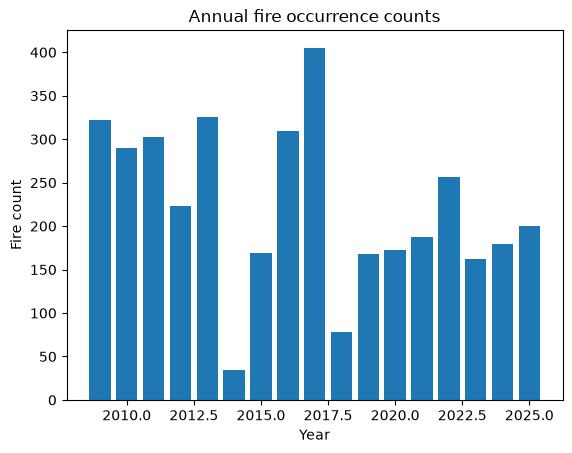

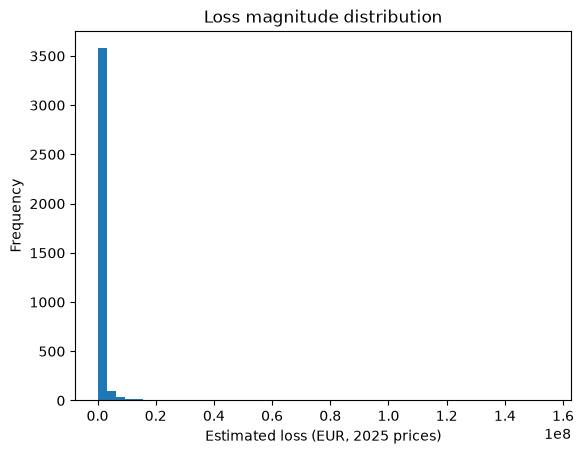

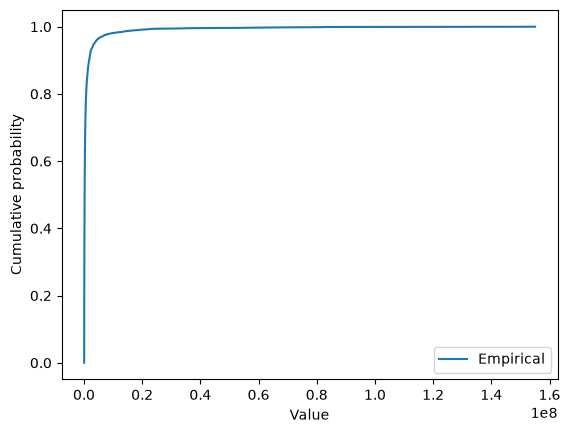

In [12]:
plot_annual_fire_counts(processed_df)
plt.show()

plot_loss_histogram(processed_df, loss_col="Estimated_Loss_EUR_2025", xlabel="Estimated loss (EUR, 2025 prices)")
plt.show()

plot_empirical_cdf(processed_df["Estimated_Loss_EUR_2025"].values)
plt.show()

## Cross-validation against independent aggregate sources

Compares the real large-fire dataset against live OWID/GWIS annual
aggregates (all fire sizes), as an independent sanity check rather than a
reconciliation - the two sources measure different things (see "Data gaps
and assumptions").

In [13]:
owid_counts = fetch_annual_fire_counts()
owid_counts = owid_counts[owid_counts["year"] <= MAX_YEAR]
gwis_area = fetch_annual_burnt_area()
gwis_area = gwis_area[gwis_area["year"] <= MAX_YEAR]

real_annual = processed_df.groupby(processed_df["Date"].dt.year).agg(
    real_large_fire_count=("Burned_Area_ha", "size"),
    real_large_fire_area_ha=("Burned_Area_ha", "sum"),
)
real_annual.index.name = "year"

comparison = real_annual.join(owid_counts.set_index("year")).join(gwis_area.set_index("year"))
comparison["large_fire_vs_gwis_ratio_pct"] = (
    comparison["real_large_fire_area_ha"] / comparison["burnt_area_ha"] * 100
)
print(comparison)
print()

def area_ratio(frame):
    return frame["real_large_fire_area_ha"].sum() / frame["burnt_area_ha"].sum() * 100

total_ratio = area_ratio(comparison)
early_ratio = area_ratio(comparison.loc[:2019])
recent_ratio = area_ratio(comparison.loc[2020:])
n_count_exceed = int((comparison["real_large_fire_count"] > comparison["fire_count"]).sum())
n_count_years = int(comparison["fire_count"].notna().sum())

print(f"Total-to-total area ratio, all years (properly weighted): {total_ratio:.1f}%")
print(f"  2009-2019: {early_ratio:.1f}%    2020-2025: {recent_ratio:.1f}%")
print("A simple mean of per-year ratios would overstate the disagreement, since it weights")
print("small years (e.g. 2021) the same as large ones (e.g. 2017).")
print()
print(f"Years where the >= {MIN_FIRE_AREA_HA} ha count exceeds OWID's all-fire count: {n_count_exceed} of {n_count_years}")
print()

rolling = comparison[["real_large_fire_area_ha", "burnt_area_ha"]].rolling(3).sum().dropna()
rolling["ratio_3yr_pct"] = rolling["real_large_fire_area_ha"] / rolling["burnt_area_ha"] * 100
print("3-year rolling ratio (smooths out single-year noise):")
print(rolling["ratio_3yr_pct"].round(0).astype(int))


      real_large_fire_count  real_large_fire_area_ha  fire_count  \
year                                                               
2009                    322                    74816         NaN   
2010                    290                   120693         NaN   
2011                    303                    64442         NaN   
2012                    223                    95379       815.0   
2013                    326                   153408      1143.0   
2014                     34                    11550       175.0   
2015                    169                    47286       600.0   
2016                    310                   160444       975.0   
2017                    405                   562348      1365.0   
2018                     78                    37144       209.0   
2019                    168                    33181       359.0   
2020                    172                    61280       323.0   
2021                    187                    2

## Event threshold sensitivity: 30 ha vs 100 ha

Per the PRD's Phase 1 technical decision, the 30 ha event definition is
re-run at 100 ha (ICNF treats 100 ha and above as a "major" fire). Does not
replace the 30 ha dataset used for the rest of this notebook and for
Phases 2-4; it exists to show what the alternative threshold would look
like before that choice is revisited.


In [14]:
threshold_compare = {}
for threshold in (30, 100):
    events = load_effis_fire_database(min_area_ha=threshold)
    by_year = events.groupby(events["Date"].dt.year)["Burned_Area_ha"].agg(n="size", total_ha="sum")
    dispersion = by_year["n"].var() / by_year["n"].mean()
    median_by_year = events.groupby(events["Date"].dt.year)["Burned_Area_ha"].median()
    rho, pval = stats.spearmanr(by_year["n"], median_by_year)
    threshold_compare[threshold] = {
        "events": len(events),
        "pct_of_30ha_area": by_year["total_ha"].sum(),
        "mean_events_per_year": by_year["n"].mean(),
        "count_dispersion": dispersion,
        "count_vs_median_size_rho": rho,
        "count_vs_median_size_p": pval,
    }

comp = pd.DataFrame(threshold_compare).T
comp["pct_of_30ha_area"] = comp["pct_of_30ha_area"] / comp.loc[30, "pct_of_30ha_area"] * 100
comp = comp.rename(columns={"pct_of_30ha_area": "pct_of_30ha_total_area"})
print(comp.round(2))
print()
print(f"100 ha keeps {threshold_compare[100]['events']} of {threshold_compare[30]['events']} events")
print(f"({threshold_compare[100]['events'] / threshold_compare[30]['events']:.0%}) and "
      f"{comp.loc[100, 'pct_of_30ha_total_area']:.1f}% of the 30 ha threshold's total area.")
print("Overdispersion and the count-size dependence found at 30 ha both persist at 100 ha")
print("(dispersion stays far above 1; the correlation weakens slightly but the sample is smaller).")
print("Decision (per the checkpoint): keep 30 ha as the primary threshold, since it retains 98.2%")
print("of mapped area and does not depend on ICNF's administrative 'major fire' definition.")


     events  pct_of_30ha_total_area  mean_events_per_year  count_dispersion  \
30   3785.0                  100.00                222.65             40.96   
100  1893.0                   94.66                111.35             39.13   

     count_vs_median_size_rho  count_vs_median_size_p  
30                       0.57                    0.02  
100                      0.46                    0.06  

100 ha keeps 1893 of 3785 events
(50%) and 94.7% of the 30 ha threshold's total area.
Overdispersion and the count-size dependence found at 30 ha both persist at 100 ha
(dispersion stays far above 1; the correlation weakens slightly but the sample is smaller).
Decision (per the checkpoint): keep 30 ha as the primary threshold, since it retains 98.2%
of mapped area and does not depend on ICNF's administrative 'major fire' definition.


## Domain validation: order-of-magnitude sanity check

Per the PRD's Domain Validation criterion, checked here early rather than
waiting for Phase 4: does the modeled annual loss land in the right ballpark
for well-documented years? Now on real per-fire data, this is a genuine
test of the calibration constant, not just the synthesis method.

In [15]:
year_of_fire = processed_df["Date"].dt.year
annual_modeled_loss = processed_df.groupby(year_of_fire)["Estimated_Loss_EUR"].sum()          # each year's own euros
annual_modeled_loss_2025 = processed_df.groupby(year_of_fire)["Estimated_Loss_EUR_2025"].sum()  # 2025 euros
print("Modeled annual loss, central scenario (EUR m):")
print(pd.DataFrame({"that year's prices": annual_modeled_loss / 1e6,
                    "2025 prices": annual_modeled_loss_2025 / 1e6}).round(0))

# Published benchmarks (sourced, see data/raw/published_loss_benchmarks.csv); all in 2024 euros
bench = pd.read_csv(RAW_DIR / "published_loss_benchmarks.csv").set_index("measure")
modeled_2024 = annual_modeled_loss.loc[2024]
model_area_2024 = processed_df.loc[year_of_fire == 2024, "Burned_Area_ha"].sum()
agif_area = bench.loc["burnt_area_agif", "value"]
forest = bench.loc["forest_sector_loss", "value"]
insured = bench.loc["insured_claims_provisional", "value"]

print()
print("2024 area check, mainland (independent of the EUR calibration):")
print(f"  EFFIS mainland >= {MIN_FIRE_AREA_HA} ha: {model_area_2024:,.0f} ha  vs  AGIF: {agif_area:,.0f} ha  ({model_area_2024 / agif_area:.1%})")
print()
print("2024 loss comparison, in 2024 euros (modeled total vs the only euro figures found):")
print(f"  Modeled total, central scenario:        EUR {modeled_2024 / 1e6:,.0f}m")
print(f"  Forest-sector loss only (AGIF):         EUR {forest / 1e6:,.0f}m  = {forest / modeled_2024:.0%} of modeled; implies EUR {forest / agif_area:,.0f}/ha")
print(f"  + insured claims, Sep fires (APS):      EUR {(forest + insured) / 1e6:,.0f}m  = {(forest + insured) / modeled_2024:.0%} of modeled")
print("  These are components of loss, not a total: they exclude uninsured homes and businesses,")
print("  agriculture, public infrastructure and firefighting cost. No published TOTAL economic loss")
print("  for 2023 or 2024 was found, so the PRD's 'within ~20% of published reports' test cannot")
print("  be run for those years. The modeled figure is above the measured floor, as it should be,")
print("  but that is a bracket, not a validation.")
print()
official_2017 = pd.read_csv(RAW_DIR / "loss_anchors.csv").set_index("anchor_id").loc["pt_2017_total", "damage_eur"]
official_2017_2025 = official_2017 * hicp[PRICE_BASE_YEAR] / hicp[2017]
central_2017 = annual_modeled_loss.loc[2017]
print(f"2017 against the official EU Solidarity Fund total (EUR {official_2017 / 1e6:,.0f}m in 2017 euros = EUR {official_2017_2025 / 1e6:,.0f}m in 2025 euros):")
area_by_year = processed_df.groupby(year_of_fire)["Burned_Area_ha"].sum()
scen = pd.DataFrame(
    {row.label: area_by_year * row.eur_per_ha / 1e6 for row in calibration_df.itertuples()}
).loc[[2017, 2023, 2024, 2025]].round(0)
scen.columns = [f"{c} (EUR m, 2025 prices)" for c in scen.columns]
print(scen)
print(f"  in 2017 euros the central scenario gives EUR {central_2017 / 1e6:,.0f}m = {central_2017 / official_2017:.0%} of the official total;")
print("  the high scenario matches it by construction.")
print("  The central figure is not calibrated to 2017, but 2017 is ~15% of its long-run numerator and its")
print("  price year is assumed, so this is only a partly independent check. What it shows is the size of the")
print(f"  non-linearity (2017 per-ha damage ~{calibration_df.loc[calibration_df['label'] == 'high', 'eur_per_ha'].iloc[0] / eur_per_ha:.1f}x the central figure).")
print()
print("Other reference points:")
print("  2022 Serra da Estrela fire (EMSR618): ~25,000 ha; 2024 Central Madeira fire (EMSR748): >5,000 ha")
print("  (both from earlier research, not re-verified; EMSR748 is Madeira and outside the mainland scope).")
print(f"  Copernicus EMS, Sept 2024 mainland fires: {bench.loc['ems_burnt_area_all_activations', 'value']:,.1f} ha across 4 areas of interest;")
print(f"  EMSR760 (Sever do Vouga) alone: {bench.loc['ems_emsr760_burnt_area', 'value']:,.1f} ha.")
top2024 = processed_df[year_of_fire == 2024].nlargest(1, "Burned_Area_ha").iloc[0]
print(f"  Largest 2024 record here: {top2024['Burned_Area_ha']:,.0f} ha ({top2024['Location']}, {top2024['Date']:%Y-%m-%d}).")
print("  That exceeds EMSR760's 21,262 ha, so it cannot be that activation's perimeter as-is; it may merge")
print("  adjacent fires or be a different fire. Not confirmed either way.")


Modeled annual loss, central scenario (EUR m):
      that year's prices  2025 prices
Date                                 
2009               127.0        172.0
2010               207.0        277.0
2011               114.0        148.0
2012               174.0        219.0
2013               281.0        352.0
2014                21.0         27.0
2015                87.0        109.0
2016               297.0        368.0
2017              1057.0       1291.0
2018                71.0         85.0
2019                63.0         76.0
2020               117.0        141.0
2021                50.0         59.0
2022               217.0        240.0
2023                68.0         71.0
2024               309.0        316.0
2025               640.0        640.0

2024 area check, mainland (independent of the EUR calibration):
  EFFIS mainland >= 30 ha: 137,564 ha  vs  AGIF: 137,667 ha  (99.9%)

2024 loss comparison, in 2024 euros (modeled total vs the only euro figures found):
  Modeled to

## Data gaps and assumptions

**Frequency and severity data (real, per-fire):**
- Source: EFFIS's Rapid Damage Assessment fire database, obtained via
  EFFIS's official Data Request Form as a one-time manual submission for
  Portugal (first for 2010-2024, then a second export for 2000-2025 that
  returned 2008-04-26 to 2026-09-17). The second export's 2010-2024
  records are identical to the first (same ids, areas, dates and
  locations), so it replaces it as the single raw file. Nothing before
  2008 came back. This is a static file committed to `data/raw/`, not a
  live API - no reproducibility drift risk for this component.
- **Record used: 2009-2025 (17 years).** 2008 is excluded (the product
  starts 2008-04-26 and only 33 records fall in that year; its area is
  79% of GWIS's, so it looks real but low-information and coverage of the
  early season is uncertain). 2026 is excluded (a partial year, to 17
  September). 2025 is included but provisional and may be revised.
- **Scope: mainland Portugal, a mapped fire of at least 30 ha, applied
  explicitly.** EFFIS's documentation says the MODIS product maps fires of
  roughly 30 ha or larger (an estimated 75-80% of burnt area). That holds
  through 2018, but the export's `map_source` becomes `modis/sentinel2` in
  2019 and `sentinel2` from 2020, and the smallest mapped fire drops from
  ~12-24 ha to 1 ha: 63-82% of 2020-2025 rows are under 30 ha versus
  1.5-9% in 2009-2018. Unfiltered, mean annual counts jump from ~255
  (2009-2019) to ~824 (2020-2025) for a sensor reason, not a hazard reason.
  An explicit `MIN_FIRE_AREA_HA = 30` filter is applied to every year,
  which keeps 98.2% of mapped area and gives 239 vs 193 mean events/year
  for 2009-2019 vs 2020-2025, i.e. no upward trend. This is a deliberate
  scope choice for a tail-risk model, and it keeps frequency and severity
  defined on one consistent threshold.
- **Cleaning waterfall:** 9,262 raw records -> 9,212 mainland (50 Madeira
  and Azores records dropped, since the model is mainland-only) -> 7,900 in
  the 2009-2025 window (33 from 2008 and 1,279 from 2026 dropped) -> 7,809
  with area > 0 (91 non-physical records dropped; EFFIS's own notes mention
  small/unmapped islands within a burn scar) -> 7,749 after removing 60
  redundant duplicate copies (same parish, area and timestamp under a
  different `id`; 115 rows sit in duplicate sets, 60 are the extra copies;
  all 1-12 ha, ~157 ha in total, concentrated in 2021-2025) -> **3,785
  events at >= 30 ha** (3,964 below 30 ha dropped).
- **Count discrepancy vs OWID: resolved.** An earlier pass found EFFIS
  large-fire counts *exceeding* OWID's all-fire counts (e.g. 2022: 1,204
  unfiltered vs 465) and attributed it to MODIS-vs-VIIRS methodology. The
  real cause was the unfiltered Sentinel-2 records described above: with
  the 30 ha filter the EFFIS count (257 in 2022) is below OWID's in every
  year with OWID data (0 of 14 exceed it).
- **Area discrepancy vs GWIS: narrowed, not closed.** An earlier "mean
  ratio" of 116.6% was misleading (an unweighted mean over-weights small
  years). The weighted total-to-total ratio is 104.7% unfiltered and
  **102.9%** with the 30 ha filter. By period, the filtered ratio is
  101.2% for 2009-2019 and 106.5% for 2020-2025 (111.7% unfiltered), so the
  sub-30 ha records explain close to half of the recent-years excess and an
  ~6.5% overshoot remains. Not caused by the duplicate records; candidate
  causes not yet checked are GWIS's most recent years being less finalized,
  Sentinel-2 10 m perimeters delineating burn scars differently from 250 m
  MODIS, and whether GWIS's "Portugal" includes the islands (which would
  make the mainland ratio slightly understated). Small enough not to change
  the model's conclusions; left as a documented open question.
- **Frequency is strongly overdispersed.** Annual counts range from 34
  (2014) to 405 (2017) around a mean of ~223, a variance-to-mean ratio of
  ~41 where a Poisson process gives ~1. Phase 2 should expect a plain
  Poisson to fail goodness-of-fit and compare a Negative Binomial.
- **Frequency and severity are not independent, and polygons are not
  independent events.** Annual count vs median fire size: Spearman rho 0.57
  (permutation p = 0.019, n = 17), holding without 2017 (p = 0.023). A model
  that draws counts and sizes independently gives an annual-area SD of ~64k
  ha against ~133k ha observed, and essentially never produces a 2017-sized
  year. Fires also cluster: on 2017-10-15, 33 polygons burned 196,476 ha
  (the largest single polygon that year is 67,521 ha), and the top 10
  fire-days hold 35% of all area. Grouping by start date gives 1,283
  fire-day events; overdispersion falls to ~5.5 and the count-size
  correlation is no longer significant (rho 0.25), but the annual-area SD is
  still ~1.8x the independent value. Phase 2/3 plan: model fire-day events,
  add a year-level severity factor, and cross-check with a whole-year
  bootstrap. **To revisit:** the fire-day definition is a simple first
  choice (same start date, national scope); multi-day windows in the style
  of a treaty hours clause should be tested later.
- **2025 is a second extreme year of a different character.** 200 events
  (9th of 17 by count) but 278,917 ha (2nd by area, after 2017), with 83% of
  the area burned in August and four polygons on 2025-08-10 alone covering
  113,675 ha: an average number of fires, but very large ones. It is
  provisional. The revised PRD's "roughly 274,000-278,000 ha" for 2025 is
  consistent (this is ~0.3% above the top of that range); GWIS shows
  266,907 ha.
- `Location` is the real NUTS2-level region (EFFIS's `admlvl2` field).
  Finer `admlvl3`/`admlvl5` fields exist in the raw file but are
  intentionally unused, matching the PRD's explicit exclusion of
  sub-regional/spatial granularity from scope.

**Loss calibration (EUR/ha):**
- No source publishes verified EUR loss per individual fire, and published
  totals for the same event differ by roughly an order of magnitude per
  hectare depending on what they include (Pedrogao Grande 2017: EUR 497m
  government estimate vs ~EUR 200m direct losses). EUR/ha is therefore a
  **three-point range, not a calibrated constant**, stated in **2025
  euros** (the PRD's price basis). Each source figure is restated from the
  euros of its own year with Eurostat's Portuguese HICP (2015 = 100; uplift
  x1.022 from 2024, x1.194 from 2021, x1.221 from 2017): low ~497 (2024
  forest-sector loss/ha, 487 in 2024 euros; a floor), central ~2,296
  (ICNF-derived 1975-2021 average via OECD/press, 1,923 in source prices),
  high ~3,167 (2017 EU Solidarity Fund total direct damage of EUR 1,458m /
  the 562,348 ha mainland area in this dataset, 2,593 in 2017 euros).
  Evidence and candidate anchors: `data/raw/loss_anchors.csv`.
- **The central figure's price year is an assumption.** It is a cumulative
  1975-2021 total in mixed-year euros, so it cannot be restated exactly. It
  is treated as 2021 euros (`CENTRAL_PRICE_YEAR`), the smallest possible
  uplift; the true 2025-euro value is likely higher, and it is the least
  certain of the three points.
- **Two per-fire loss columns:** `Estimated_Loss_EUR` is in the euros of
  the fire's own year and `Estimated_Loss_EUR_2025` is in 2025 euros. This
  assumes real EUR/ha is constant over time (no exposure or value growth;
  the PRD's value-growth sensitivity covers that), and HICP is a general
  consumer index, not a construction-cost index, so reconstruction-cost
  inflation may differ.
- **Only one official mainland total sits inside the data window (2017).**
  Madeira 2016 (EUR 157m over 5,409 ha, ~EUR 36,000/ha in 2025 prices, ~11x
  the high scenario, and unverified) is excluded as out of scope. 2003
  (>EUR 800m over ~425,000 ha, ~EUR 2,900/ha in 2025 prices) would be a
  second catastrophic-year anchor that lands between the central and high
  scenarios, but both figures need verifying and it predates the EFFIS
  window. The central scenario sits below both catastrophic anchors, as
  expected if ordinary years cost less per hectare; ordinary years have no
  anchor of their own. The 2017 EUSF total is derived by arithmetic (0.832%
  of GNI against a EUR 1,051.6m threshold at 0.6%) from figures seen in
  search results; the primary document was not opened.
- **Modeled loss is burnt area times a constant** per scenario: the loss
  distribution has exactly the shape of the area distribution, and VaR/ES in
  euros are the area VaR/ES rescaled. Best read as a burnt-area model with
  a euro scale. The per-fire columns use the central scenario.
- **External checks, and what they can and cannot show.** 2024 mainland
  burnt area agrees with AGIF (137,564 ha vs 137,667 ha, 99.9%). 2017: in
  2017 euros the central scenario gives EUR 1,057m, 72% of the official
  EUR 1,458m, a partly independent check (the central figure isn't
  calibrated to 2017, but 2017 is part of its numerator and its price year
  is assumed); the high scenario matches by construction. For 2024 the only
  published euro figures are components (forest-sector loss EUR 67m,
  provisional insured claims above EUR 17m, together ~EUR 84m) against a
  central-scenario total of ~EUR 309m in 2024 euros: a bracket, not a
  validation, since no published total economic loss for 2023 or 2024 was
  found. The 2025 season (provisional, 278,917 ha) gives EUR 139m / 640m /
  883m (2025 euros) across the low / central / high scenarios; no published
  2025 loss figure has been looked up yet. The PRD's "within published
  range" test needs a defined benchmark before Phase 4.

**Superseded approach**: an earlier version of this notebook synthesized
individual fire records to match real annual aggregates, since the real
per-fire database hadn't arrived yet. That synthesis step has been fully
replaced now that real data is available - see `docs/worklog.md` for that
history.